In [1]:
#> imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#> module imports
sys.path.insert(1, '../../opus/')
import plot
import lensing
import modules.geometry as geometry

In [10]:
#> image positions file
file = 'all_quads_positions.csv'
pos = pd.read_csv(file)

#> list of 'accepted' quad names
file = 'quad_names.csv'
accepted_names = pd.read_csv(file)
accepted = set(accepted_names['Name'].astype(str).str.strip())

pos

,Name,Comp,alias,From,dRA,dDEC,edDEC,edRA,RAJ2000,DEJ2000,...,BibCode,RApdeg,DEpdeg,zsource,zdef,ezsource,ezdef,zsBibCode,zlBibCode,arrival_order
0,2MASSJ11344050-2103230,A,-,2026 Ducourant,0.752180958,-0.779,-,-,173.6691022,-21.05643417,...,2018MNRAS.476..927L,173.6691008,-21.05643527,2.77,-,-,-,-,-,CBAD
1,2MASSJ11344050-2103230,B,-,2026 Ducourant,1.481036092,0.976,-,-,173.6693192,-21.05594667,...,2018MNRAS.476..927L,173.669319,-21.05594666,2.77,-,-,-,-,-,CBAD
2,2MASSJ11344050-2103230,C,-,2026 Ducourant,-1.195462056,-1.552,-,-,173.6685225,-21.05664889,...,2018MNRAS.476..927L,173.6685207,-21.05665055,2.77,-,-,-,-,-,CBAD
3,2MASSJ11344050-2103230,D,-,2026 Ducourant,-0.495544798,0.587,-,-,173.6687308,-21.05605472,...,2018MNRAS.476..927L,173.6687279,-21.0560536,2.77,-,-,-,-,-,CBAD
4,2MASSJ11344050-2103230,G,-,2026 Ducourant,0,0,-,-,173.6688783,-21.05621778,...,2018MNRAS.476..927L,173.6688785,-21.05621777,2.77,-,-,-,-,-,CBAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,J1330-0905,A,Persephone's Torch,SLED,0,0,-,-,-,-,...,https://arxiv.org/abs/2604.13152,-,-,2.2245,-,0.0005,-,-,-,-
311,J1330-0905,B,Persephone's Torch,SLED,-0.4911,-0.0437,-,-,-,-,...,https://arxiv.org/abs/2604.13152,-,-,2.2245,-,0.0005,-,-,-,-
312,J1330-0905,C,Persephone's Torch,SLED,-0.2423,-0.0918,-,-,-,-,...,https://arxiv.org/abs/2604.13152,-,-,2.2245,-,0.0005,-,-,-,-
313,J1330-0905,D,Persephone's Torch,SLED,-0.2845,0.7672,-,-,-,-,...,https://arxiv.org/abs/2604.13152,-,-,2.2245,-,0.0005,-,-,-,-


In [11]:
#> iterating through galaxies, ordering
names, arrival_order, ordered_images = [], [], []
for name in pos['Name'].unique():

    #> skipping names
    if name not in accepted: continue

    names.append(name)

    #> galaxy & sorting based on component
    lens = pos[ pos['Name'] == name]
    lens = lens.sort_values('Comp')

    #> collecting images and ordering
    images = lens[['dRA', 'dDEC']][:-1].to_numpy(dtype=float)
    ordered_ims = lensing.arrivalOrder(images, 0.0, 0.0)
    ordered_images.append(np.array(ordered_ims))

    #> order
    dummy = pd.DataFrame(ordered_ims, columns=['dRA', 'dDEC'])
    dummy2 = lens[['Comp', 'dRA', 'dDEC']]
    dummy2 = dummy2.astype({'dRA': float, 'dDEC': float})
    merged = dummy.merge(dummy2)
    order = merged['Comp'].to_numpy()
    order = [x.strip() for x in order]
    order_str = ''.join(order)
    arrival_order.append(order_str)

#> converting
names = np.array(names)
arrival_order = np.array(arrival_order)
ordered_images = np.array(ordered_images)

mo = pd.DataFrame({'Name': names, 'mo_order': arrival_order})

### ***GraL Time Delays***
---

In [12]:
#> imports
import astropy.io.fits as fits
from astropy.table import Table

In [13]:
#> reading time delays
file = './2026_GraL/gaia_full_table.fit'

#> position table
table = Table.read(file, hdu=2)
df = table.to_pandas()

#> binary to normal
for key in df.keys():
    try:
        df[key] = [ x.decode('utf-8') for x in df[key] ]
    except:
        continue

# df = df[df['Name'].apply(lambda x: x in accepted_names['Name'])]
df

,Name,RAJ2000,DEJ2000,BibCode,tAB,e_tAB,tAC,e_tAC,tAD,e_tAD,tBC,e_tBC,tBD,e_tBD,tCD,e_tCD,Ref,recno
0,DESJ0029-3814,7.419252,-38.240599,2025arXiv250402932D,-6.50,3.000,-6.6,2.7,43.1,2.4,-2.0,3.5,46.7,2.9,49.9,2.7,2025Dux,1
1,J0030-1525,7.563728,-15.417792,2025arXiv250402932D,9.30,1.600,-19.3,3.3,NaN,NaN,-28.5,3.5,NaN,NaN,NaN,NaN,2025Dux,2
2,HE0047-1756,12.615965,-17.669410,2020A&A...642A.193M,-10.80,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020Millon_b,3
3,DESJ0053-2012,13.435089,-20.209228,2025arXiv250402932D,-26.70,2.600,-20.2,2.6,-90.2,6.7,6.3,2.0,-63.5,5.9,-70.2,6.1,2025Dux,4
4,Q0142-100,26.319451,-9.754881,2020A&A...640A.105M,-97.70,16.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020Millon,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,J2205-3727,331.434469,-37.450389,2025arXiv250402932D,-1.80,2.500,0.2,4.3,12.3,1.8,1.7,4.7,14.0,2.7,11.9,4.4,2025Dux,69
69,HS2209+1914,332.876362,19.486972,2023ApJ...950...37M,-21.96,1.448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023Meyer,70
70,SDSSJ2222+2745,335.535891,27.759839,2015ApJ...813...67D,47.70,6.000,-722.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015Dahle,71
71,J2305+3714,346.482476,37.239088,2026MNRAS.546ag023B,52.20,2.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026Burkhonov,72


In [14]:
#> arrival order from time delays
def TDOrder(df):

    #> columns
    tds = df[['tAB', 'tAC', 'tAD']].to_numpy(dtype=float)[0]
    tds = np.hstack([tds, [0.0]]).reshape(4,1)
    
    tds_e = df[['e_tAB', 'e_tAC', 'e_tAD']].to_numpy(dtype=float)[0]
    tds_e = np.hstack([tds_e, [0.0]]).reshape(4,1)
    
    tds = np.hstack([tds, 
                     tds_e, 
                     np.array(['B', 'C', 'D', 'A']).reshape(4,1), 
                     np.array(['tAB', 'tAC', 'tAD', 'tAA']).reshape(4,1)], dtype=object)

    #> ordering
    ordered = tds[tds[:, 0].argsort()]
    order = ordered[::-1][:,2]
    
    return order, tds

TDOrder(df[ df['Name'] == 'DESJ0029-3814'])

(array(['D', 'A', 'B', 'C'], dtype=object),
 array([[-6.5, 3.0, 'B', 'tAB'],
        [-6.6, 2.700000047683716, 'C', 'tAC'],
        [43.1, 2.4000000953674316, 'D', 'tAD'],
        [0.0, 0.0, 'A', 'tAA']], dtype=object))

In [38]:
#> iterating thru every galaxy in list
accepted = set(accepted_names['Name'].astype(str).str.strip())
td_names, td_order, all_tds = [], [], []
for name in df['Name']:

    #> rejecting other names
    if name not in accepted: continue
    if name not in ['DESJ0053-2012']:continue
    
    #> time delays for this galaxy [days]
    lens = df[ df['Name'] == name ]
    tds  = lens[['tAB', 'tAC', 'tAD']].to_numpy(dtype=float)[0]  # days
    
    #> checking for nans
    if np.isnan(tds).any(): continue   # skip if ANY delay is missing

    #> getting order
    order, tds = TDOrder(lens)
    order_str = ''.join(order)
    td_order.append(order_str)
    td_names.append(name)
    all_tds.append(tds)
    # if np.isnan(tds).all(): continue # skip only if ALL delays are missing
    
td_order = np.array(td_order)
td_names = np.array(td_names)
all_tds = np.array(all_tds)

In [16]:
#> creating pandas
td = pd.DataFrame({'Name': td_names, 'td_order': td_order})
cols = ['Name', 'tAB', 'e_tAB', 'tAC', 'e_tAC', 'tAD', 'e_tAD']

#> merging
merge = pd.merge(td, mo, on='Name')
merge = pd.merge(merge, df[cols], on='Name')
merge

,Name,td_order,mo_order,tAB,e_tAB,tAC,e_tAC,tAD,e_tAD
0,DESJ0029-3814,DABC,CADB,-6.50,3.0,-6.60,2.7,43.10,2.4
1,DESJ0053-2012,ACBD,CABD,-26.70,2.6,-20.20,2.6,-90.20,6.7
2,WG0214-2105,BADC,CABD,10.70,0.7,-5.00,0.6,-2.90,1.4
3,WISE025942.9-163543,CABD,CADB,-9.00,1.7,8.30,1.4,-17.50,3.4
4,J0420-4037,CBAD,CBDA,1.70,2.4,7.90,2.6,-7.20,5.1
5,HE0435-1223,ACBD,ADBC,-9.00,0.8,-0.80,0.8,-13.80,0.8
6,GraLJ065904.1+162909,CADB,CDAB,-16.10,2.2,262.20,11.1,-14.20,12.8
7,RXJ0911+0551,DBCA,DBAC,10.70,1.7,5.60,1.8,160.00,8.9
8,SDSS0924+0219,BADC,BADC,3.70,0.9,-17.50,3.4,-1.60,3.6
9,RXJ1131-1231,BACD,CBAD,1.60,0.7,-1.00,1.2,-92.50,1.9


### ***Checking Individual Lenses***
---

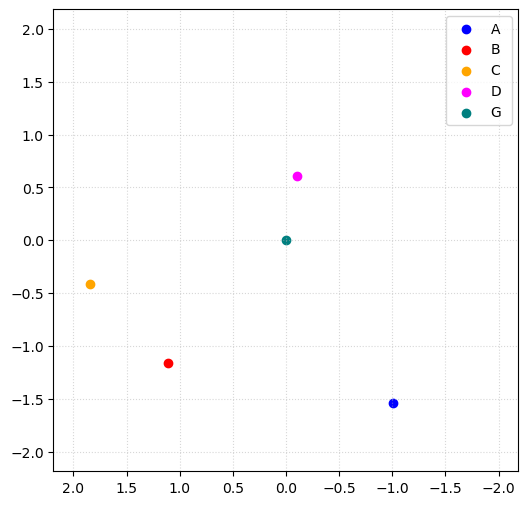

In [36]:
#> lens index
idx = 1

#> parsing data
lens = pos[ pos['Name'] == merge.loc[idx]['Name'] ]
images = lens[['dRA', 'dDEC']].to_numpy(dtype=float)
comp = lens['Comp'].to_numpy()

#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.grid(ls=':', alpha=0.5)

#> plotting
for i in range(len(images)):
    ax.scatter(images[i,0], images[i,1], label=comp[i])

#> adjusting
plot.toBox(ax)
plot.ticks(ax)
ax.invert_xaxis()

plt.legend()
plt.show()